# Real Estate — A Keras Experiment Ladder

The neural-network deep dive for the regression walkthrough, and the most systematic experiment in
the unit. Model variants are built in **four themed groups**: sweep batch size on the simplest
possible network; holding that fixed, sweep width and depth together including deliberately extreme
values; sweep the learning rate on the resulting three-layer standard; then layer on regularization
and normalization, individually and combined.

Every variant shares the same 100-epoch budget and the **same manual K-fold cross-validation
loop**, so the final comparison is honest — mean and spread, not a lucky split. Synthetic demos
make these techniques look optional; on real, noisy data the payoff is dramatic.

## Learning objectives

- Run a controlled ladder of experiments, changing one factor per group
- Sweep batch size, width, depth, and learning rate, and read each one's effect
- Recognize the failure modes at extreme width, extreme depth, and extreme learning rate
- Apply Dropout and BatchNormalization, alone and together
- Evaluate every variant by cross-validation and compare means *and* spreads

## Background

This notebook assumes the preprocessed table from `U1_RealEstate-2_Preprocess`, the Keras
`Sequential` API and the regression network from `U1-3_Regression-5_KerasIntro`, the learning-rate
U-curve from `U1-3_Regression-6_KerasLossVsLR`, and K-fold cross-validation from
`U1-3_Regression-3_CrossValidation`.

Each architectural idea is introduced at the rung that first uses it.

**Prerequisites:** `U1-3_Regression-5_KerasIntro` (Keras regression),
`U1-3_Regression-6_KerasLossVsLR` (learning rate),
`U1_RealEstate-2_Preprocess` (the dataset)

**Dataset:** `Real Estate Data_preprocessed.csv` — the encoded output of
`U1_RealEstate-2_Preprocess`.

**References:** https://keras.io/api/layers/regularization_layers/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load preprocessed data

Notebook 2 (`U1_RealEstate-2_Preprocess`) already cleaned this dataset, engineered the
features, and encoded every column - so we load its output and get straight to modeling.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data_preprocessed.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Columns: 195 entries, Type to Sale Condition_Sale between family members
dtypes: float64(4), int64(167), object(24)
memory usage: 1.9+ MB


,Type,Zoning Class,Lot Frontage,Lot Area,Lot Shape,Land Contour,Lot Config,Land Slope,Nbhd,Location Condition,Bldg Type,House Style,Overall Qual,Overall Cond,Year,Year Remod Add,Roof Style,Roof Material,Exterior Primary,Masonry/Veneer Area,Exterior Qual,Exterior Cond,Foundation,Basement Height,Basement Cond,Basement Exposure,Basement Finish,Heating Qual,Central Air,Electrical,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Kitchen Qual,Total Rooms Above Grade,Functionality,Fireplaces,Fireplce Qual,Garage Type,Year Garage,Garage Finish,Garage Cars,Garage Qual,Garage Cond,Paved Drive,Pool Qual,Fence,...,Exterior Primary_Stucco,Exterior Primary_Wood Shingles,Exterior Primary_Wood Siding,Foundation_Brick & Tile,Foundation_Cinder Block,Foundation_Slab,Foundation_Stone,Foundation_Wood,Basement Exposure_Avg Exposure,Basement Exposure_Good Exposure,Basement Exposure_Min Exposure,Basement Exposure_No Basement,Basement Finish_Avg Living Quarters,Basement Finish_Avg Rec Room,Basement Finish_Below Avg Living Quarters,Basement Finish_Good Living Quarters,Basement Finish_Low Quality,Basement Finish_No Basement,Electrical_60 AMP Fuse Box and mostly Romex wiring (Fair),Electrical_Fuse Box over 60 AMP and all Romex wiring (Average),Functionality_Major Deductions 1,Functionality_Minor Deductions 1,Functionality_Minor Deductions 2,Functionality_Moderate Deductions,Garage Type_Basement Garage,Garage Type_Built-In (Garage with Room),Garage Type_Car Port,Garage Type_Detached from home,Garage Type_More than one type of garage,Garage Type_No Garage,Garage Finish_Finished,Garage Finish_No Garage,Garage Finish_Rough Finished,Paved Drive_Dirt/Gravel,Paved Drive_Partial Pavement,Fence_Good Privacy,Fence_Good Wood,Fence_Minimum Privacy,Fence_Minimum Wood/Wire,Sale Type_Contract 15% Down payment regular terms,Sale Type_Contract Low Down,Sale Type_Contract Low Down payment and low interest,Sale Type_Contract Low Interest,Sale Type_Court Officer Deed/Estate,Sale Type_Home just constructed and sold,Sale Type_Warranty Deed - Cash,"Sale Condition_Abnormal Sale - trade, foreclosure, short sale","Sale Condition_Allocation - two linked properties with separate deeds, typically condo with a garage unit",Sale Condition_Home was not completed when last assessed (associated with New Homes),Sale Condition_Sale between family members
0,2-STORY 1946 & NEWER,Resid Low Density,65.0,8450,Regular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2003,2003,Gable,Composite Shingle,Vinyl Siding,196.0,3,2,Poured Contrete,3,2,No Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,8,Typical Functionality,0,0,Attached to home,2003.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1-STORY 1946 & NEWER,Resid Low Density,80.0,9600,Regular,Level,Frontage on 2 sides,Gentle,Veenker,Adjacent Feeder St,1-family Detached,1 story,6,8,1976,1976,Gable,Composite Shingle,Metal Siding,0.0,2,2,Cinder Block,3,2,Good Exposure,Avg Living Quarters,4,1,Standard Circuit Breakers & Romex,0,1,2,0,3,1,2,6,Typical Functionality,1,2,Attached to home,1976.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2-STORY 1946 & NEWER,Resid Low Density,68.0,11250,Slightly irregular,Level,Inside lot,Gentle,College Creek,Normal,1-family Detached,2 story,7,5,2001,2002,Gable,Composite Shingle,Vinyl Siding,162.0,3,2,Poured Contrete,3,2,Min Exposure,Good Living Quarters,4,1,Standard Circuit Breakers & Romex,1,0,2,1,3,1,3,6,Typical Functionality,1,2,Attached to home,2001.0,Rough Finished,2,2,2,Paved,0,No Fence,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2-STORY 1945 & OLDER,Resid Low Density,60.0,9550,Slightly irregular,Level,Corner lot,Gentle,

### 1.1 Features and target

In [3]:
y = df['Sale Price'].values.astype(float)

# The preprocessed file now also carries the original string columns; keep only the numeric
# ones (dummies + numeric features) so the matrix is all-float for Keras.
X = df.drop(columns=['Sale Price']).select_dtypes(exclude='object').values.astype(float)

print(f"X: {X.shape}")
print(f"y: {y.shape}, mean price ${y.mean():,.0f}")

X: (1256, 170)
y: (1256,), mean price $171,974


## 2. The experiment: many variants, manual CV for each

A single train/test split can flatter (or slander) a model by luck. So every variant below is
evaluated with the **same hand-written K-fold loop**: 5 folds, a *fresh* copy of the model per
fold, and per-fold test MAE, MAPE, and $R^2$. Every variant also **explicitly sets its own batch
size** - nothing is left to an unstated default.

We build **each variant's network explicitly, layer by layer** — no factory function hiding the
architecture behind a config dict. Read a variant's model cell and you can see exactly what changed
from the one before it.

`run_cv(model, X, y, ...)` takes an already-built, compiled model and runs the manual
cross-validation. One detail that is easy to get wrong: the feature scaler is **fit on the
training fold only** — fitting it on all data leaks the test fold into training. `Sale Price` is
never scaled, so every metric is already in dollars, with no inverse-transform needed. `run_cv`
also **tracks MAE, MAPE, and $R^2$ each epoch** and plots them — one axis per metric, every fold
overlaid and coloured by train vs. test — so you can watch all the curves converge (or diverge).

In [4]:
from tqdm import tqdm
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from keras.models import clone_model
from keras.metrics import MeanAbsolutePercentageError, R2Score

def run_cv(
    model,
    X,
    y,
    scale_X=False,
    epochs=100,
    n_splits=5,
    batch_size=32,
    patience=15,
    seed=42,
):
    """Manual K-fold cross-validation of one already-built, compiled model.

    A fresh copy of the model (fresh weights AND a fresh optimizer) is trained on each fold, so the
    folds stay independent. Returns the per-fold metrics DataFrame."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    rows = []
    histories = []
    for fold, (train_idx, test_idx) in enumerate(tqdm(list(kf.split(X)), ncols=60), start=1):
        X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
        y_tr, y_te = y[train_idx].copy(), y[test_idx].copy()

        # The feature scaler is fit on the TRAINING fold only - anything else leaks test data.
        if scale_X:
            x_scaler = StandardScaler()
            X_tr = x_scaler.fit_transform(X_tr)
            X_te = x_scaler.transform(X_te)

        # Sale Price is never scaled - reshape to 2-D only because the Keras R2Score metric
        # expects it, not because the values themselves change.
        y_tr_fit = y_tr[:, np.newaxis]
        y_te_fit = y_te[:, np.newaxis]

        # Fresh copy of the SAME architecture each fold: clone_model rebuilds it with new random
        # weights, and we re-create the optimizer from the passed model so its state resets too.
        # We also track MAPE and R2 every epoch (MAE is already the loss) for the history plot.
        fold_model = clone_model(model)
        fold_model.compile(
            optimizer=type(model.optimizer).from_config(model.optimizer.get_config()),
            loss=model.loss,
            metrics=[MeanAbsolutePercentageError(name='MAPE'), R2Score(name='R2')],
        )

        early_stopping = EarlyStopping(monitor='val_loss', patience=patience,
                                       restore_best_weights=True)
        history = fold_model.fit(X_tr, y_tr_fit,
                                 epochs=epochs, batch_size=batch_size,
                                 validation_data=(X_te, y_te_fit),
                                 verbose=0, callbacks=[early_stopping])
        histories.append(history.history)

        # Predict on both splits - already in dollars, since y was never scaled.
        y_tr_pred = fold_model.predict(X_tr, verbose=0)[:, 0]
        y_te_pred = fold_model.predict(X_te, verbose=0)[:, 0]

        rows.append({
            'fold': fold,
            'test MAE':   mean_absolute_error(y_te, y_te_pred),
            'test MAPE':  mean_absolute_percentage_error(y_te, y_te_pred),
            'test R2':    r2_score(y_te, y_te_pred),
        })

    # Describe rather than list all 5 folds individually: mean/std/min/max is the honest,
    # readable summary of cross-validated performance.
    res = pd.DataFrame(rows).set_index('fold')
    display(res.describe().round(2).iloc[2:, :])
    print(f"mean test MAE: ${res['test MAE'].mean():,.0f}   "
          f"mean test MAPE: {res['test MAPE'].mean():.3f}   "
          f"mean test R2: {res['test R2'].mean():.3f}")

    # Training histories: one figure, one axis per metric, every fold overlaid, coloured by
    # train vs. test (two legend entries total).
    # - MAE: log-log, since loss drops fast early and flattens - a linear axis crushes the tail.
    # - MAPE: Keras's MeanAbsolutePercentageError reports PERCENT (e.g. 80.0, not 0.80), so we
    #   divide by 100 before plotting - matching the fraction convention everywhere else in this
    #   notebook - then a fixed [0, 1] ylim actually shows the curve instead of clipping it away.
    # - R2 is already a fraction, so [0, 1] needs no rescaling.
    metric_axes = [('MAE', 'loss', 'val_loss', None, 'loglog', 1.0),
                   ('MAPE', 'MAPE', 'val_MAPE', (0, 1), 'linear', 1 / 100),
                   ('R2', 'R2', 'val_R2', (0, 1), 'linear', 1.0)]
    train_color, test_color = '#4c72b0', '#dd8452'

    fig, axes = plt.subplots(1, len(metric_axes), figsize=(5 * len(metric_axes), 4))
    axes = np.atleast_1d(axes)
    for ax, (title, tr_key, te_key, ylim, scale, factor) in zip(axes, metric_axes):
        for i, hist in enumerate(histories):
            epochs_axis = np.arange(1, len(hist[tr_key]) + 1)
            ax.plot(epochs_axis, np.array(hist[tr_key]) * factor, color=train_color, alpha=0.7,
                    label='train' if i == 0 else None)
            ax.plot(epochs_axis, np.array(hist[te_key]) * factor, color=test_color, alpha=0.7,
                    label='test' if i == 0 else None)
        ax.set_title(title)
        ax.set_xlabel('epoch')
        ax.set_ylabel(title)
        if scale == 'loglog':
            ax.set_xscale('log')
            ax.set_yscale('log')
        if ylim is not None:
            ax.set_ylim(*ylim)
    axes[0].legend()
    fig.suptitle('Per-metric training histories (all folds)')
    plt.tight_layout()
    plt.show()

    return res

cv_results = {}

### 2.1 A. Linear baseline: batch size

On the simplest possible network - a single linear layer, no hidden layers, raw unscaled
features, `learning_rate=1.0` - sweep just the batch size: `4, 16, 64, 256`. Every variant in
this notebook uses the same `100`-epoch budget (early stopping decides when a run is actually
done), so epoch count is not part of the sweep.

#### 2.1.1 Batch size 4

A linear model (`Dense(1)`, no hidden layers), raw unscaled features, `learning_rate=1.0` (a
deliberately aggressive default) — and a batch size of `4`. Nearly one gradient update per
example: about as noisy as gradient descent gets.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:23<01:32, 23.14s/it]

 40%|██████████               | 2/5 [00:51<01:18, 26.10s/it]

 60%|███████████████          | 3/5 [01:19<00:53, 26.94s/it]

 80%|████████████████████     | 4/5 [01:47<00:27, 27.27s/it]

100%|█████████████████████████| 5/5 [02:14<00:00, 27.44s/it]

100%|█████████████████████████| 5/5 [02:14<00:00, 26.95s/it]

,test MAE,test MAPE,test R2
std,1000.19,0.01,0.01
min,14235.34,0.09,0.85
25%,14781.62,0.09,0.86
50%,15955.90,0.10,0.86
75%,16208.89,0.10,0.86
max,16591.16,0.11,0.87


mean test MAE: $15,555   mean test MAPE: 0.099   mean test R2: 0.857


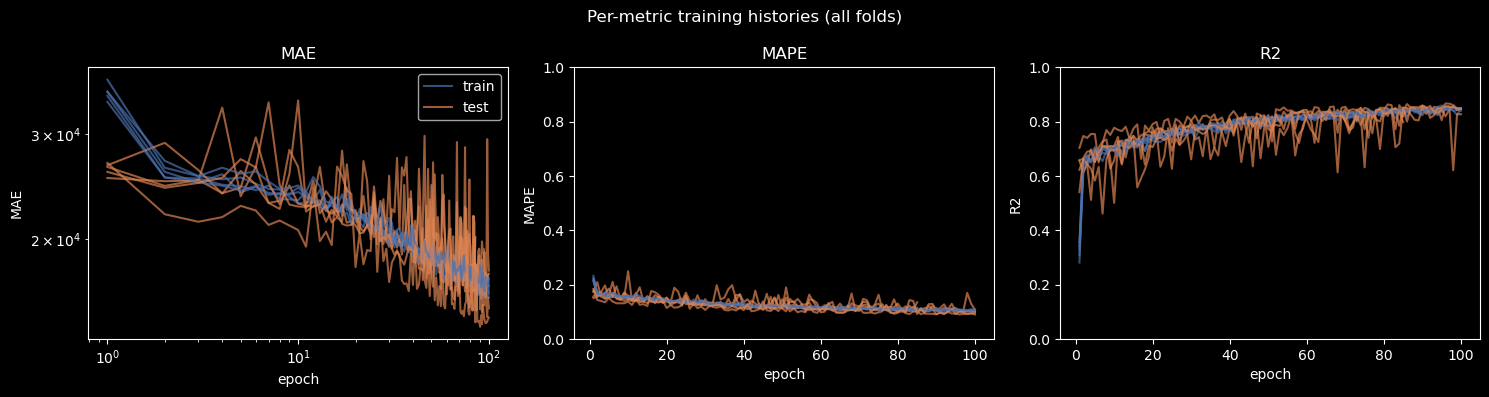

In [5]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam

# A1 - linear model, lr=1.0, raw data; batch size 4.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=1.0), loss='mae')

cv_results['A1 batch size 4'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=4,
)

#### 2.1.2 Batch size 16

Same linear model, same `lr=1.0` — batch size `16`.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:12<00:49, 12.42s/it]

 40%|██████████               | 2/5 [00:24<00:36, 12.27s/it]

 60%|███████████████          | 3/5 [00:36<00:24, 12.21s/it]

 80%|████████████████████     | 4/5 [00:49<00:12, 12.25s/it]

100%|█████████████████████████| 5/5 [01:01<00:00, 12.27s/it]

100%|█████████████████████████| 5/5 [01:01<00:00, 12.27s/it]

,test MAE,test MAPE,test R2
std,1038.68,0.01,0.01
min,15874.09,0.10,0.81
25%,16975.13,0.11,0.81
50%,17632.45,0.12,0.82
75%,18025.45,0.12,0.83
max,18567.21,0.12,0.84


mean test MAE: $17,415   mean test MAPE: 0.112   mean test R2: 0.822


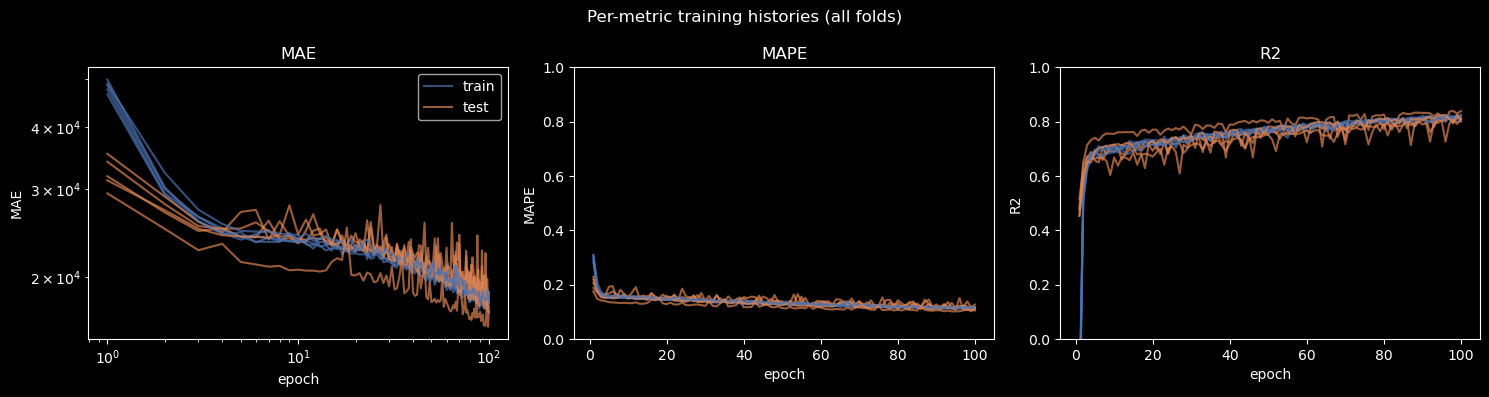

In [6]:
# A2 - same linear model, lr=1.0, raw data; batch size 16.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=1.0), loss='mae')

cv_results['A2 batch size 16'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=16,
)

#### 2.1.3 Batch size 64

Same linear model, same `lr=1.0` — batch size `64`.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:08<00:33,  8.33s/it]

 40%|██████████               | 2/5 [00:16<00:24,  8.30s/it]

 60%|███████████████          | 3/5 [00:24<00:16,  8.31s/it]

 80%|████████████████████     | 4/5 [00:33<00:08,  8.31s/it]

100%|█████████████████████████| 5/5 [00:41<00:00,  8.34s/it]

100%|█████████████████████████| 5/5 [00:41<00:00,  8.33s/it]

,test MAE,test MAPE,test R2
std,1172.40,0.01,0.02
min,18741.23,0.12,0.73
25%,20974.97,0.13,0.75
50%,21062.87,0.14,0.75
75%,21476.07,0.14,0.76
max,21639.64,0.14,0.79


mean test MAE: $20,779   mean test MAPE: 0.133   mean test R2: 0.755


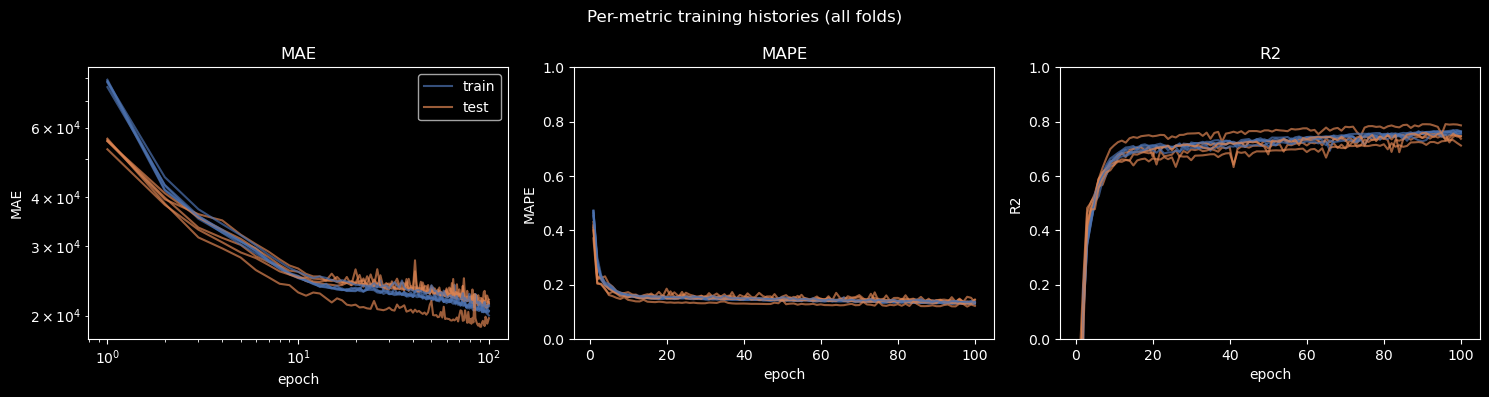

In [7]:
# A3 - same linear model, lr=1.0, raw data; batch size 64.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=1.0), loss='mae')

cv_results['A3 batch size 64'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=64,
)

#### 2.1.4 Batch size 256

Same linear model, same `lr=1.0` — batch size `256`, the largest value in this sweep.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:07<00:29,  7.27s/it]

 40%|██████████               | 2/5 [00:14<00:22,  7.34s/it]

 60%|███████████████          | 3/5 [00:21<00:14,  7.32s/it]

 80%|████████████████████     | 4/5 [00:29<00:07,  7.31s/it]

100%|█████████████████████████| 5/5 [00:36<00:00,  7.27s/it]

100%|█████████████████████████| 5/5 [00:36<00:00,  7.29s/it]

,test MAE,test MAPE,test R2
std,1360.08,0.01,0.03
min,20640.90,0.13,0.67
25%,23510.71,0.15,0.70
50%,23526.75,0.15,0.71
75%,23740.67,0.15,0.71
max,23874.21,0.15,0.75


mean test MAE: $23,059   mean test MAPE: 0.149   mean test R2: 0.710


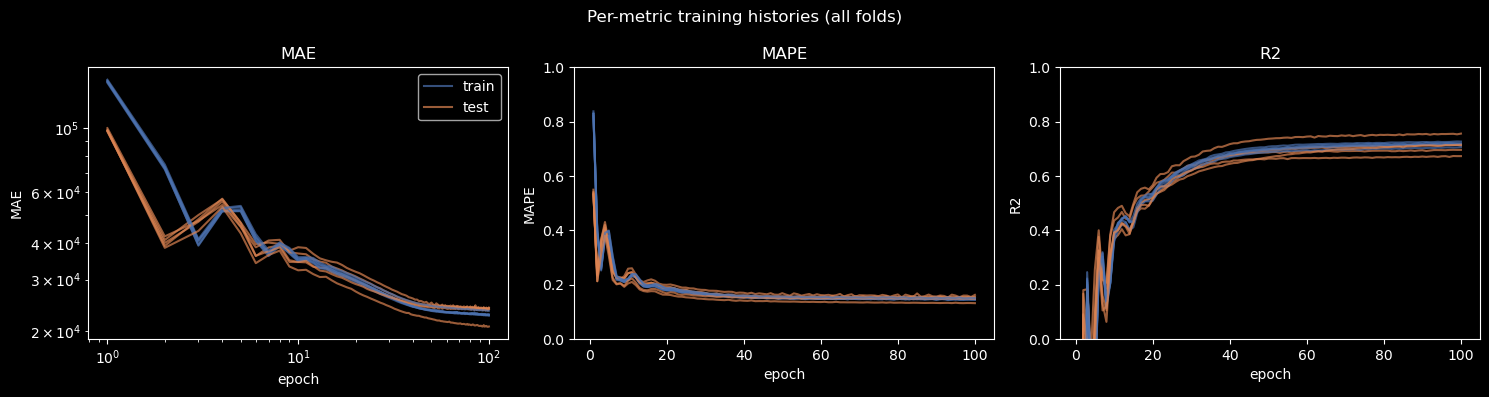

In [8]:
# A4 - same linear model, lr=1.0, raw data; batch size 256.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=1.0), loss='mae')

cv_results['A4 batch size 256'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=256,
)

### 2.2 B. Width and depth, including extreme values

With Group A's hyperparameters settled — `learning_rate=0.01`, features scaled
(`scale_X=True`), batch size `32`, `100` epochs — this group varies the network's shape along
two axes: how many `Dense` hidden layers (depth), and how many units each layer has (width).
Depth is swept from zero to four at the standard width (`20` units); width is then swept at the
standard depth (`3` layers) down to a narrow `4` units and up to a wide `1000` units. One
deliberately extreme case closes the group: `20` hidden layers at the standard width — a plain,
unassisted network far deeper than anything else in this notebook.

#### 2.2.1 0 hidden layers (linear, scaled, tuned LR)

Group A's linear model shape, but with the settled hyperparameters (`lr=0.01`, `scale_X=True`)
instead of the aggressive `lr=1.0` explored there. This is Group B's own reference point.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:09<00:38,  9.71s/it]

 40%|██████████               | 2/5 [00:19<00:29,  9.78s/it]

 60%|███████████████          | 3/5 [00:29<00:19,  9.72s/it]

 80%|████████████████████     | 4/5 [00:38<00:09,  9.72s/it]

100%|█████████████████████████| 5/5 [00:48<00:00,  9.83s/it]

100%|█████████████████████████| 5/5 [00:48<00:00,  9.79s/it]

,test MAE,test MAPE,test R2
std,1493.92,0.0,1.18
min,170433.70,1.0,-10.98
25%,170788.61,1.0,-9.11
50%,171541.68,1.0,-8.83
75%,172987.34,1.0,-8.81
max,173959.14,1.0,-7.74


mean test MAE: $171,942   mean test MAPE: 1.000   mean test R2: -9.094


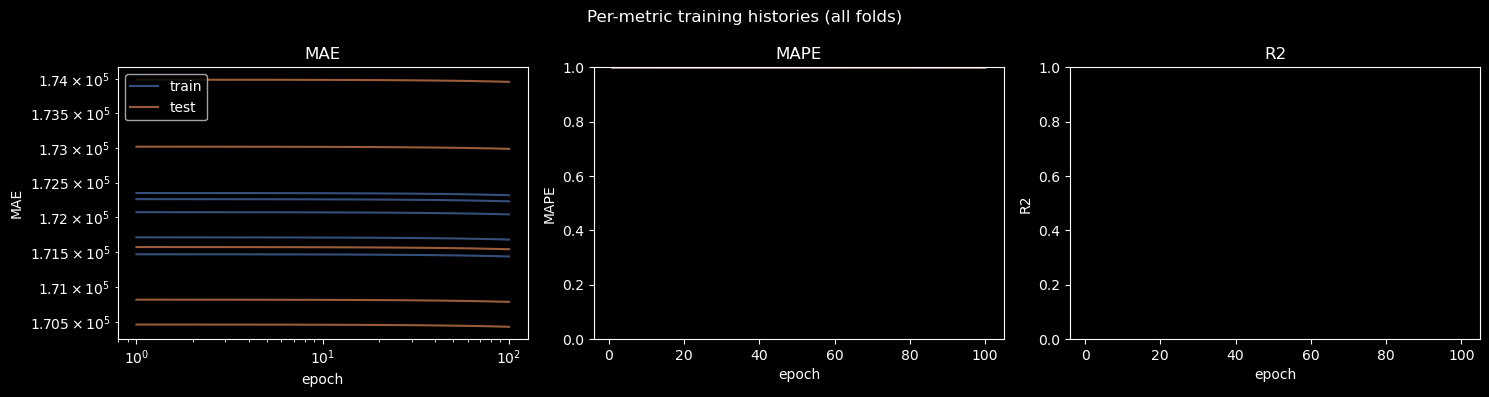

In [9]:
# B0 - linear, but with Group B's settled hyperparameters (not A's lr=1.0 probe).
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B0 0 hidden layers'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.2 1 hidden layer, width 20

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:10<00:41, 10.30s/it]

 40%|██████████               | 2/5 [00:20<00:30, 10.19s/it]

 60%|███████████████          | 3/5 [00:30<00:20, 10.29s/it]

 80%|████████████████████     | 4/5 [00:41<00:10, 10.31s/it]

100%|█████████████████████████| 5/5 [00:51<00:00, 10.33s/it]

100%|█████████████████████████| 5/5 [00:51<00:00, 10.31s/it]

,test MAE,test MAPE,test R2
std,1079.83,0.01,0.10
min,28474.92,0.18,0.30
25%,29100.01,0.18,0.38
50%,30502.83,0.19,0.41
75%,30632.84,0.20,0.50
max,30947.77,0.20,0.57


mean test MAE: $29,932   mean test MAPE: 0.192   mean test R2: 0.432


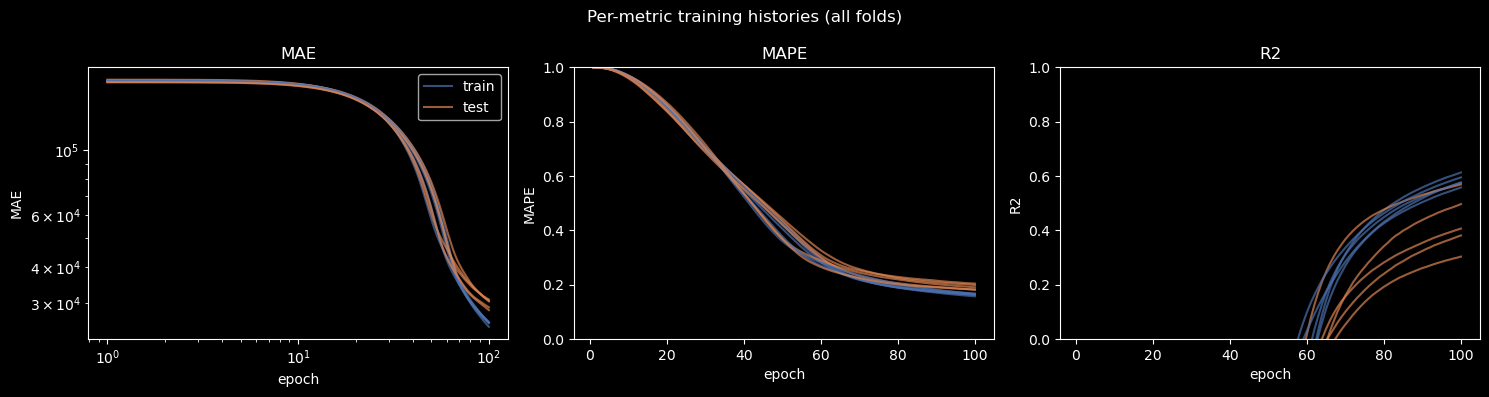

In [10]:
# B1 - one hidden layer, width 20.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B1 1 hidden layer'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.3 2 hidden layers, width 20

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:10<00:41, 10.46s/it]

 40%|██████████               | 2/5 [00:20<00:31, 10.48s/it]

 60%|███████████████          | 3/5 [00:31<00:20, 10.46s/it]

 80%|████████████████████     | 4/5 [00:42<00:10, 10.56s/it]

100%|█████████████████████████| 5/5 [00:52<00:00, 10.64s/it]

100%|█████████████████████████| 5/5 [00:52<00:00, 10.58s/it]

,test MAE,test MAPE,test R2
std,699.14,0.01,0.07
min,18209.77,0.12,0.65
25%,18211.68,0.12,0.66
50%,18533.72,0.12,0.72
75%,19343.72,0.12,0.78
max,19745.82,0.13,0.82


mean test MAE: $18,809   mean test MAPE: 0.122   mean test R2: 0.725


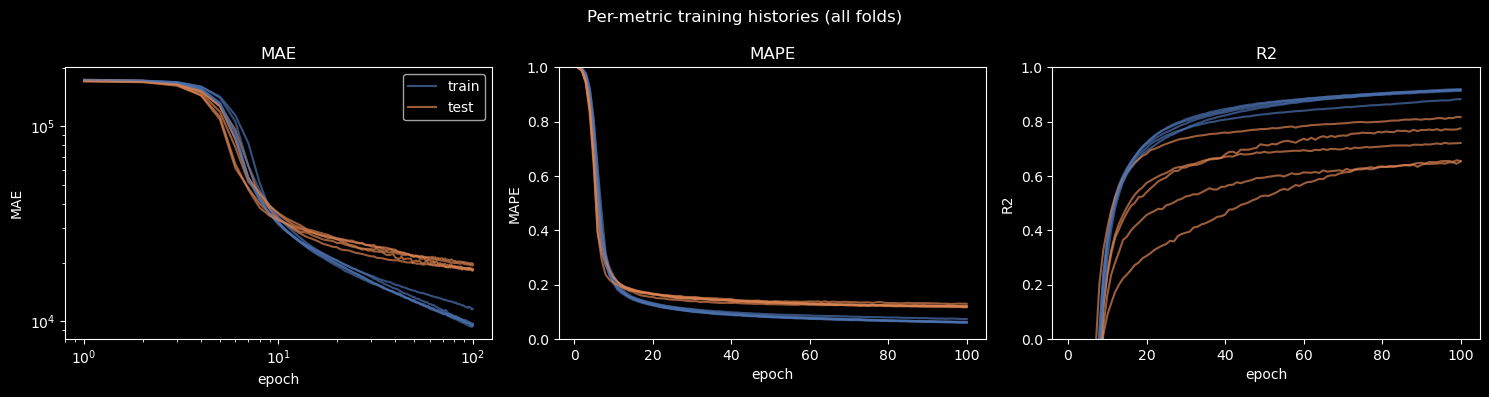

In [11]:
# B2 - two hidden layers, width 20 each.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B2 2 hidden layers'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.4 4 hidden layers, width 20

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:06<00:26,  6.55s/it]

 40%|██████████               | 2/5 [00:13<00:20,  6.91s/it]

 60%|███████████████          | 3/5 [00:23<00:16,  8.20s/it]

 80%|████████████████████     | 4/5 [00:30<00:07,  7.73s/it]

100%|█████████████████████████| 5/5 [00:38<00:00,  7.68s/it]

100%|█████████████████████████| 5/5 [00:38<00:00,  7.61s/it]

,test MAE,test MAPE,test R2
std,1180.68,0.01,0.09
min,15152.30,0.10,0.62
25%,16586.07,0.10,0.72
50%,16825.90,0.10,0.76
75%,17638.66,0.11,0.82
max,18268.22,0.12,0.86


mean test MAE: $16,894   mean test MAPE: 0.109   mean test R2: 0.757


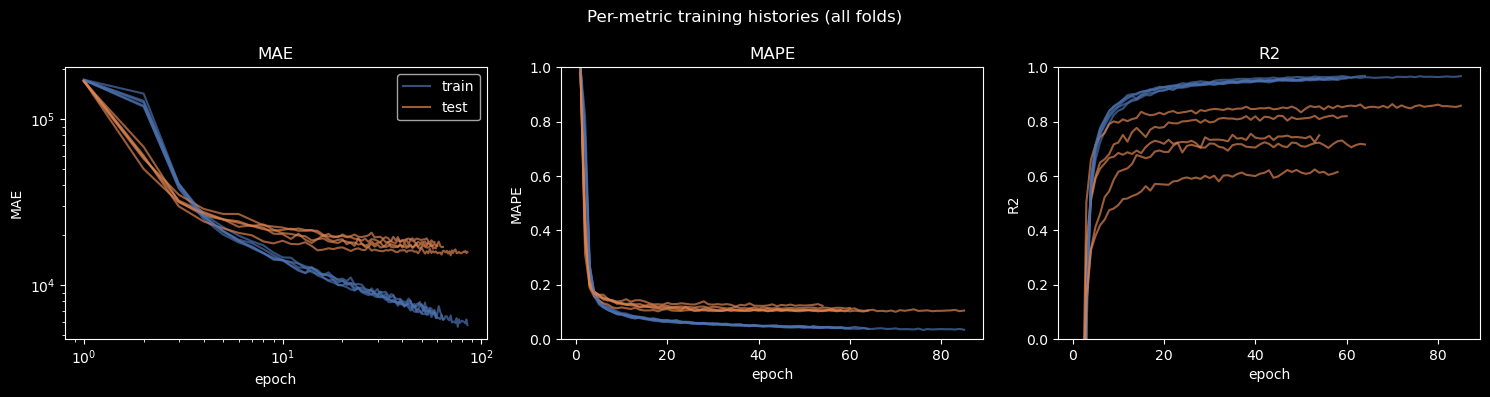

In [12]:
# B4 - four hidden layers, width 20 each.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B4 4 hidden layers'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.5 3 hidden layers, width 100 (wide)

Same standard depth (3 layers) — widen each layer from `20` units to `100`. Width and depth are
separate levers; this isolates width while holding depth at the standard.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:06<00:24,  6.12s/it]

 40%|██████████               | 2/5 [00:10<00:15,  5.14s/it]

 60%|███████████████          | 3/5 [00:17<00:12,  6.18s/it]

 80%|████████████████████     | 4/5 [00:23<00:05,  6.00s/it]

100%|█████████████████████████| 5/5 [00:28<00:00,  5.58s/it]

100%|█████████████████████████| 5/5 [00:28<00:00,  5.71s/it]

,test MAE,test MAPE,test R2
std,1396.35,0.01,0.08
min,13990.48,0.09,0.70
25%,16384.24,0.10,0.72
50%,16628.74,0.10,0.72
75%,17056.74,0.11,0.81
max,17636.11,0.11,0.89


mean test MAE: $16,339   mean test MAPE: 0.102   mean test R2: 0.768


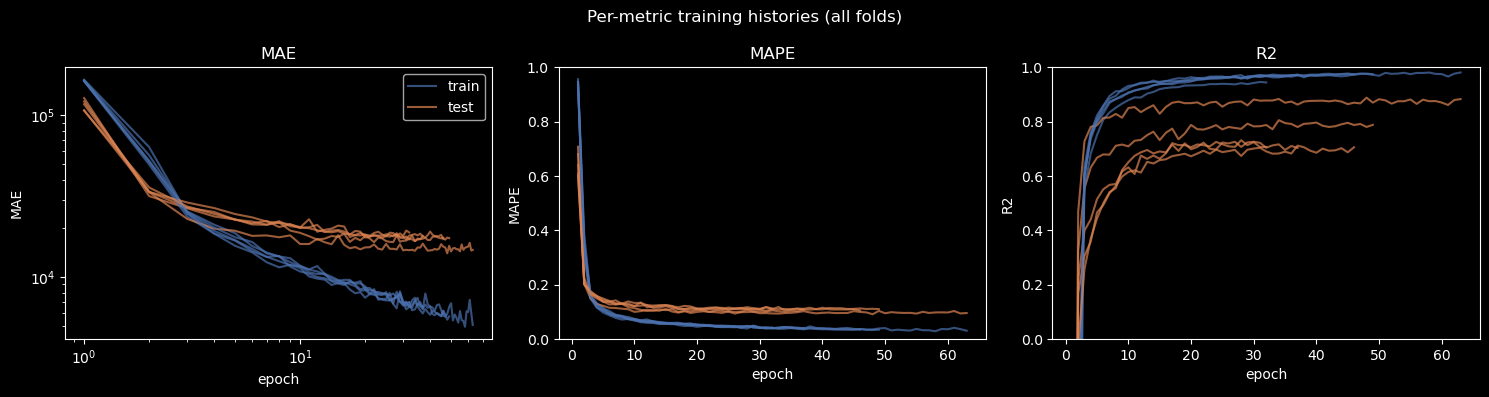

In [13]:
# B5 - same standard depth (3 layers); widen 20 -> 100 units each.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(100, activation='relu'),
    Dense(100, activation='relu'),
    Dense(100, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B5 width 100'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.6 3 hidden layers, width 4 (extreme: very narrow)

An extreme case: the standard depth, but each hidden layer squeezed down to just `4` units —
barely more capacity than the linear baseline.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:10<00:41, 10.42s/it]

 40%|██████████               | 2/5 [00:21<00:31, 10.56s/it]

 60%|███████████████          | 3/5 [00:31<00:21, 10.60s/it]

 80%|████████████████████     | 4/5 [00:42<00:10, 10.70s/it]

100%|█████████████████████████| 5/5 [00:53<00:00, 10.80s/it]

100%|█████████████████████████| 5/5 [00:53<00:00, 10.71s/it]

,test MAE,test MAPE,test R2
std,66780.62,0.38,4.33
min,17422.65,0.11,-9.11
25%,20628.73,0.13,0.16
50%,21596.13,0.14,0.61
75%,26998.11,0.19,0.65
max,170788.40,1.00,0.82


mean test MAE: $51,487   mean test MAPE: 0.314   mean test R2: -1.376


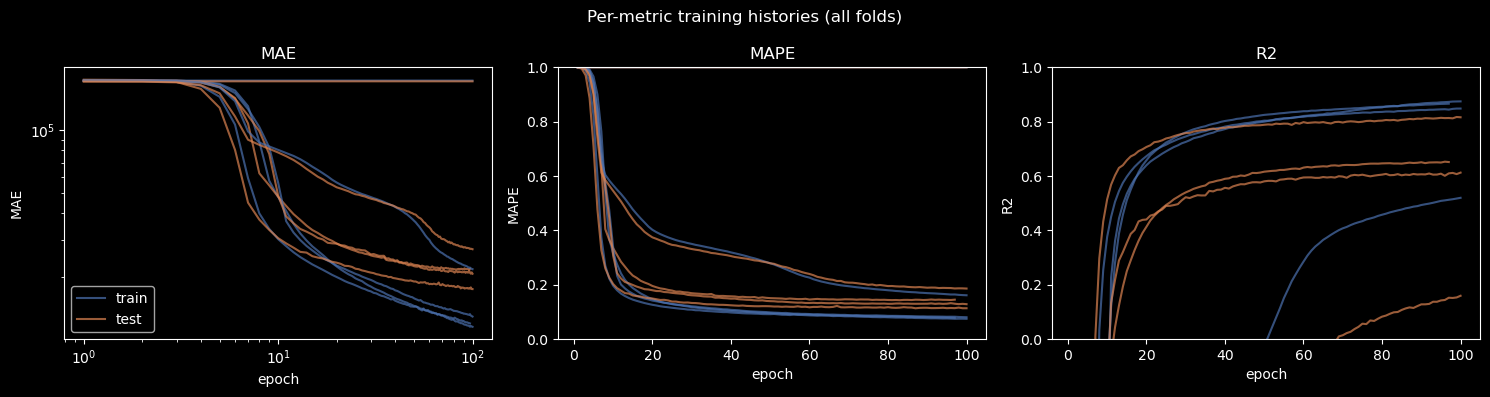

In [14]:
# B6 - EXTREME: same standard depth (3 layers); narrow to 4 units each.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B6 width 4 (extreme narrow)'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.7 3 hidden layers, width 1000 (extreme: very wide)

An extreme case: the standard depth, but each hidden layer widened to `1000` units — fifty times
the standard width.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:15<01:00, 15.25s/it]

 40%|██████████               | 2/5 [00:31<00:47, 15.98s/it]

 60%|███████████████          | 3/5 [00:51<00:35, 17.70s/it]

 80%|████████████████████     | 4/5 [01:14<00:19, 19.91s/it]

100%|█████████████████████████| 5/5 [01:29<00:00, 17.99s/it]

100%|█████████████████████████| 5/5 [01:29<00:00, 17.88s/it]

,test MAE,test MAPE,test R2
std,747.71,0.00,0.06
min,15422.32,0.10,0.74
25%,16111.49,0.10,0.76
50%,16357.95,0.10,0.82
75%,16487.11,0.11,0.84
max,17491.43,0.11,0.88


mean test MAE: $16,374   mean test MAPE: 0.103   mean test R2: 0.809


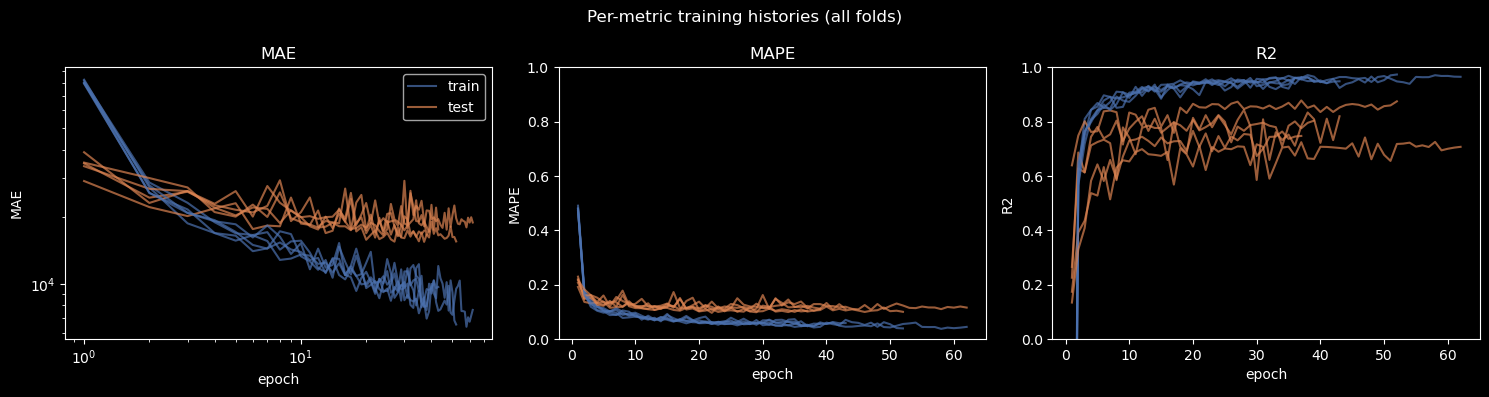

In [15]:
# B7 - EXTREME: same standard depth (3 layers); widen to 1000 units each.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B7 width 1000 (extreme wide)'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.2.8 20 hidden layers, width 20 (extreme: very deep)

An extreme case: the standard width, but twenty hidden layers deep — a plain stack of `Dense`
layers with no skip connections or normalization to keep gradients well-behaved at this depth.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:08<00:34,  8.64s/it]

 40%|██████████               | 2/5 [00:22<00:35, 11.84s/it]

 60%|███████████████          | 3/5 [00:31<00:21, 10.59s/it]

 80%|████████████████████     | 4/5 [00:41<00:10, 10.10s/it]

100%|█████████████████████████| 5/5 [00:52<00:00, 10.69s/it]

100%|█████████████████████████| 5/5 [00:52<00:00, 10.58s/it]

,test MAE,test MAPE,test R2
std,647.46,0.01,0.01
min,13894.47,0.09,0.85
25%,15251.41,0.10,0.86
50%,15300.71,0.10,0.86
75%,15395.01,0.10,0.87
max,15395.22,0.10,0.87


mean test MAE: $15,047   mean test MAPE: 0.097   mean test R2: 0.864


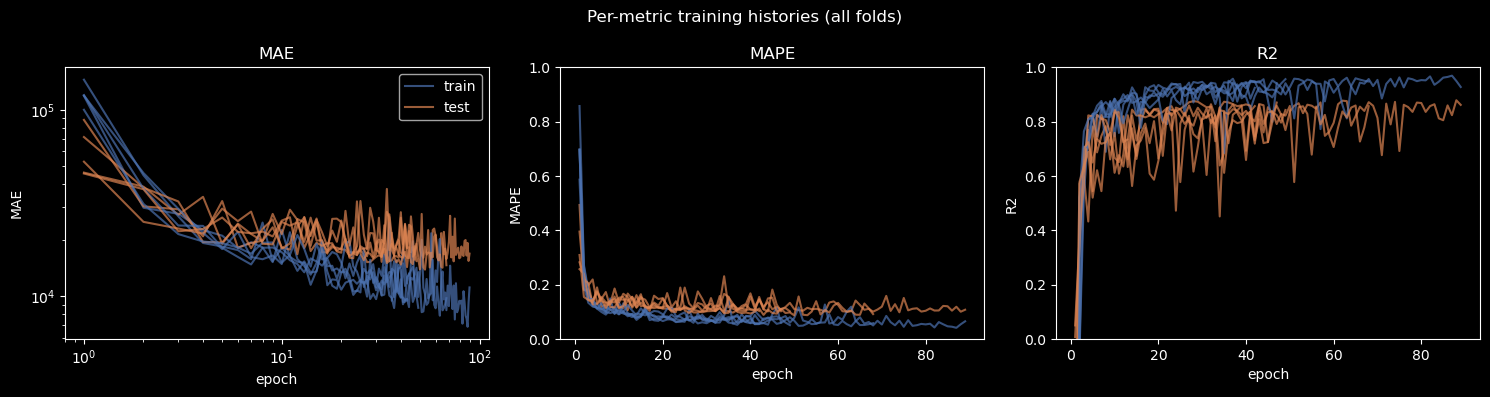

In [16]:
# B8 - EXTREME: standard width (20 units); twenty hidden layers deep, plain
# Dense stack (no skip connections, no normalization).
model = Sequential(
    [Input(shape=(X.shape[1],))]
    + [Dense(20, activation='relu') for _ in range(20)]
    + [Dense(1, activation='linear')]
)
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['B8 20 hidden layers (extreme deep)'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

### 2.3 C. Learning rate on the standard 3-layer network

Same three-layer, 20-unit, ReLU architecture used throughout Group B, features scaled
(`scale_X=True`), batch size `32`, `100` epochs — this group holds architecture fixed and sweeps
the learning rate: `0.001, 0.01, 0.1, 1.0`, four orders of magnitude. `0.01` is the value used
everywhere else in this notebook (Group B and Group D); the other three test whether a smaller
or much larger rate would have done better.

#### 2.3.1 Learning rate 0.001

Same three-layer, 20-unit standard architecture — a small, cautious learning rate, ten times
smaller than the notebook's usual `0.01`.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:10<00:43, 10.92s/it]

 40%|██████████               | 2/5 [00:21<00:32, 10.87s/it]

 60%|███████████████          | 3/5 [00:32<00:21, 10.80s/it]

 80%|████████████████████     | 4/5 [00:43<00:10, 10.77s/it]

100%|█████████████████████████| 5/5 [00:53<00:00, 10.78s/it]

100%|█████████████████████████| 5/5 [00:53<00:00, 10.80s/it]

,test MAE,test MAPE,test R2
std,1274.09,0.01,0.12
min,20328.73,0.13,0.47
25%,21507.98,0.14,0.57
50%,22755.28,0.14,0.66
75%,22990.82,0.15,0.72
max,23456.70,0.15,0.77


mean test MAE: $22,208   mean test MAPE: 0.142   mean test R2: 0.634


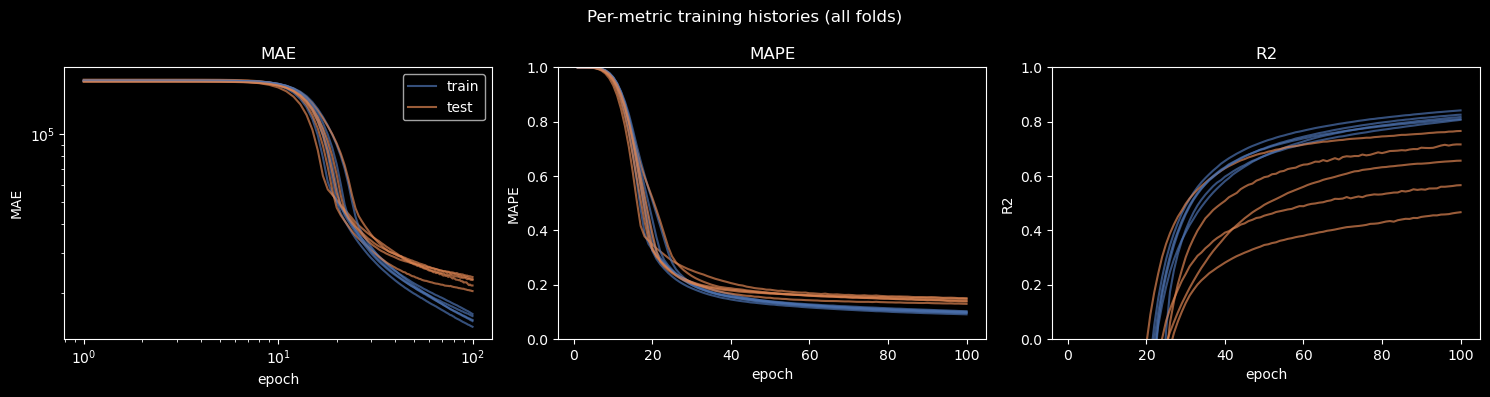

In [17]:
# C1 - standard 3-layer network; learning_rate=0.001.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

cv_results['C1 lr=0.001'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.3.2 Learning rate 0.01 (the notebook's standard)

Same three-layer, 20-unit standard architecture, `learning_rate=0.01` — the value used
everywhere else in this notebook from Group B onward. This is the reference point for the
sweep.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:09<00:39,  9.98s/it]

 40%|██████████               | 2/5 [00:20<00:30, 10.13s/it]

 60%|███████████████          | 3/5 [00:30<00:20, 10.26s/it]

 80%|████████████████████     | 4/5 [00:39<00:09,  9.83s/it]

100%|█████████████████████████| 5/5 [00:48<00:00,  9.48s/it]

100%|█████████████████████████| 5/5 [00:48<00:00,  9.73s/it]

,test MAE,test MAPE,test R2
std,1463.33,0.01,0.09
min,15046.82,0.10,0.63
25%,16946.56,0.10,0.68
50%,17136.77,0.10,0.74
75%,18442.32,0.12,0.77
max,18728.27,0.12,0.87


mean test MAE: $17,260   mean test MAPE: 0.110   mean test R2: 0.738


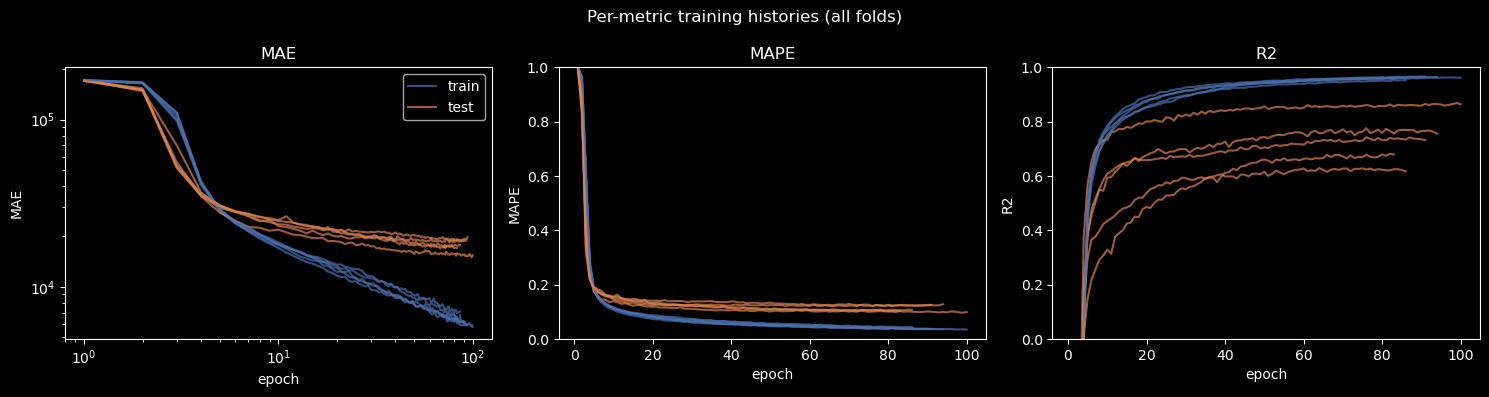

In [18]:
# C2 - standard 3-layer network; learning_rate=0.01 (the notebook's usual value).
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['C2 lr=0.01'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.3.3 Learning rate 0.1

Same three-layer, 20-unit standard architecture — ten times the notebook's usual rate.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:04<00:18,  4.65s/it]

 40%|██████████               | 2/5 [00:08<00:12,  4.26s/it]

 60%|███████████████          | 3/5 [00:14<00:09,  4.90s/it]

 80%|████████████████████     | 4/5 [00:21<00:05,  5.81s/it]

100%|█████████████████████████| 5/5 [00:30<00:00,  6.92s/it]

100%|█████████████████████████| 5/5 [00:30<00:00,  6.08s/it]

,test MAE,test MAPE,test R2
std,2125.68,0.01,0.14
min,15709.28,0.10,0.50
25%,16381.08,0.10,0.63
50%,18179.99,0.12,0.73
75%,20017.38,0.12,0.76
max,20495.23,0.13,0.87


mean test MAE: $18,157   mean test MAPE: 0.115   mean test R2: 0.697


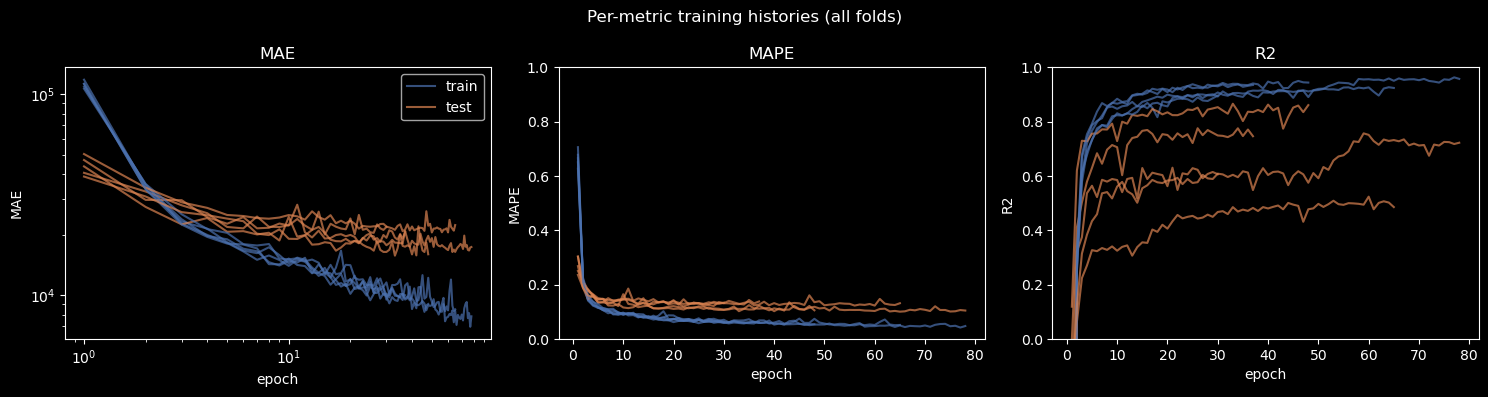

In [19]:
# C3 - standard 3-layer network; learning_rate=0.1.
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.1), loss='mae')

cv_results['C3 lr=0.1'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.3.4 Learning rate 1.0

Same three-layer, 20-unit standard architecture — the same aggressive rate Group A tested on
the linear model, now on the full three-layer network.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:10<00:42, 10.57s/it]

 40%|██████████               | 2/5 [00:14<00:20,  6.95s/it]

 60%|███████████████          | 3/5 [00:19<00:11,  5.89s/it]

 80%|████████████████████     | 4/5 [00:24<00:05,  5.38s/it]

100%|█████████████████████████| 5/5 [00:30<00:00,  5.68s/it]

100%|█████████████████████████| 5/5 [00:30<00:00,  6.09s/it]

,test MAE,test MAPE,test R2
std,67225.44,0.38,4.15
min,17369.08,0.11,-8.49
25%,18063.22,0.12,0.72
50%,18283.13,0.12,0.74
75%,18509.99,0.13,0.82
max,168373.97,0.98,0.85


mean test MAE: $48,120   mean test MAPE: 0.291   mean test R2: -1.073


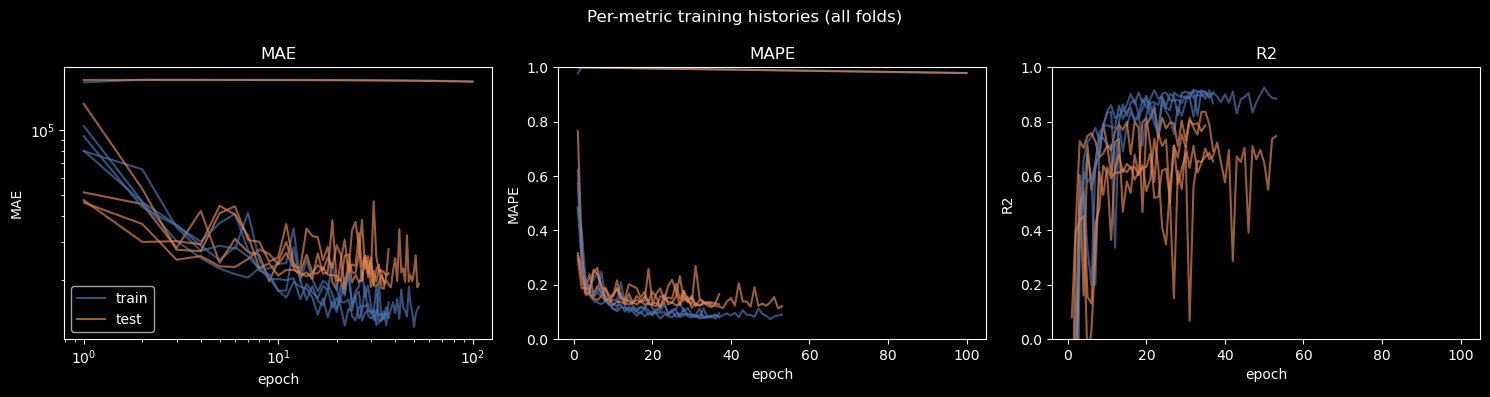

In [20]:
# C4 - standard 3-layer network; learning_rate=1.0 (the aggressive value from Group A).
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=1.0), loss='mae')

cv_results['C4 lr=1.0'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

### 2.4 D. Regularization and normalization

Same three-layer, 20-unit, ReLU network as the standard, same fixed batch size/learning
rate/scaling/epoch budget as every variant since B — each variant here adds one or more
regularization/normalization techniques on top, so their effects can be compared against the
plain standard and against each other.

#### 2.4.1 Add Dropout

`Dropout(0.25)` after the first two hidden layers only — not the third, right before the output
— alone, no BatchNormalization in this variant.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:05<00:23,  5.88s/it]

 40%|██████████               | 2/5 [00:16<00:26,  8.74s/it]

 60%|███████████████          | 3/5 [00:22<00:15,  7.50s/it]

 80%|████████████████████     | 4/5 [00:30<00:07,  7.62s/it]

100%|█████████████████████████| 5/5 [00:35<00:00,  6.73s/it]

100%|█████████████████████████| 5/5 [00:35<00:00,  7.12s/it]

,test MAE,test MAPE,test R2
std,1846.74,0.01,0.16
min,17107.39,0.11,0.44
25%,19506.28,0.12,0.58
50%,20263.99,0.12,0.73
75%,20326.37,0.13,0.80
max,22218.42,0.14,0.80


mean test MAE: $19,884   mean test MAPE: 0.122   mean test R2: 0.670


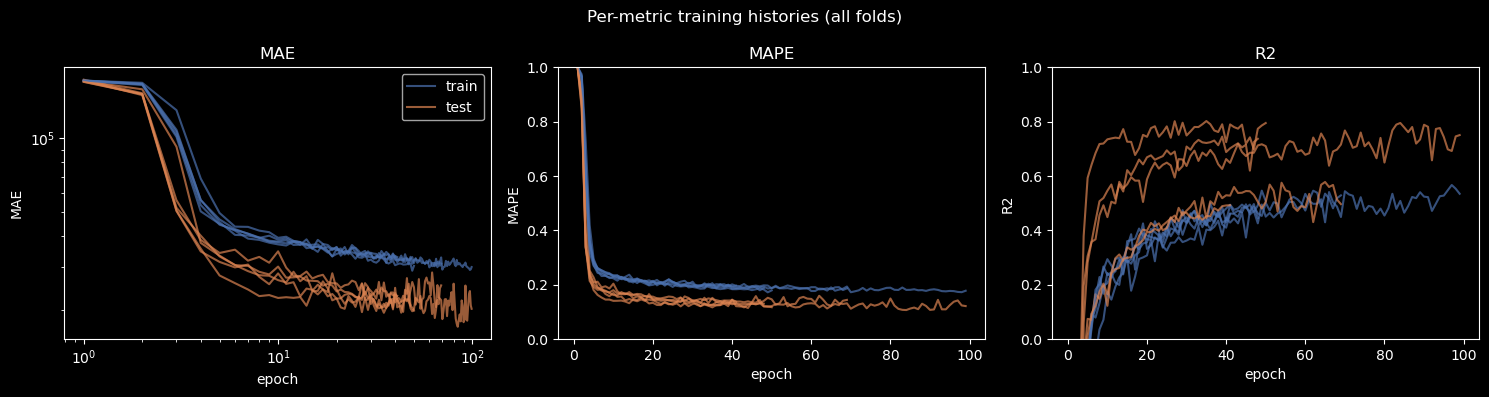

In [21]:
# D1 - Dropout(0.25) after the first two hidden layers only (not the third), alone.
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(20, activation='relu'),
    Dropout(0.25),

    Dense(20, activation='relu'),
    Dropout(0.25),

    Dense(20, activation='relu'),

    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['D1 Dropout'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.4.2 Add BatchNormalization

`BatchNormalization()` between each hidden layer's linear transform and its activation
(`Dense(..., activation=None) -> BatchNormalization() -> Activation('relu')`), alone — no Dropout
in this variant.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:06<00:25,  6.34s/it]

 40%|██████████               | 2/5 [00:12<00:18,  6.14s/it]

 60%|███████████████          | 3/5 [00:21<00:15,  7.70s/it]

 80%|████████████████████     | 4/5 [00:29<00:07,  7.81s/it]

100%|█████████████████████████| 5/5 [00:38<00:00,  7.97s/it]

100%|█████████████████████████| 5/5 [00:38<00:00,  7.63s/it]

,test MAE,test MAPE,test R2
std,696.00,0.01,0.02
min,12011.64,0.08,0.86
25%,12417.82,0.08,0.89
50%,12970.62,0.08,0.90
75%,13414.35,0.09,0.90
max,13704.06,0.09,0.91


mean test MAE: $12,904   mean test MAPE: 0.083   mean test R2: 0.889


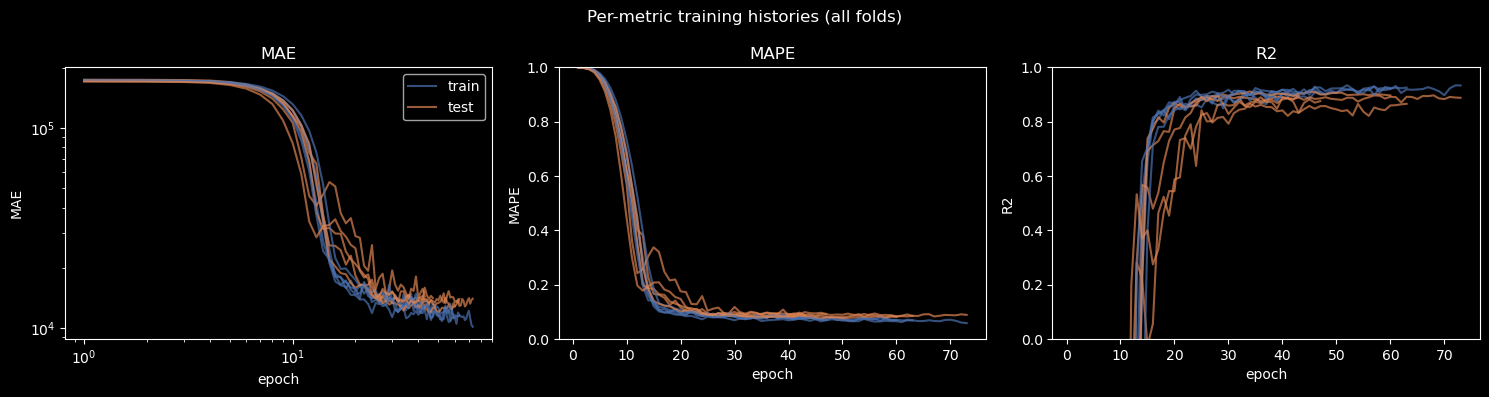

In [22]:
# D2 - BatchNormalization between each linear transform and its activation, alone.
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(20),                      # no activation yet
    BatchNormalization(),           # normalize the raw pre-activation signal
    Activation('relu'),             # activation comes AFTER normalization

    Dense(20),
    BatchNormalization(),
    Activation('relu'),

    Dense(20),
    Activation('relu'),

    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['D2 BatchNorm'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
    scale_X=True,
)

#### 2.4.3 Add Dropout and BatchNormalization together

Both techniques on the same three-layer network: `BatchNormalization()` between each linear
transform and its activation, followed by `Dropout(0.25)`, on all three hidden layers. Compare
against C1 and C2 individually to see whether combining them helps, or whether they interfere
with each other.

  0%|                                 | 0/5 [00:00<?, ?it/s]

 20%|█████                    | 1/5 [00:04<00:19,  4.90s/it]

 40%|██████████               | 2/5 [00:12<00:19,  6.61s/it]

 60%|███████████████          | 3/5 [00:17<00:11,  5.68s/it]

 80%|████████████████████     | 4/5 [00:21<00:05,  5.24s/it]

100%|█████████████████████████| 5/5 [00:26<00:00,  5.01s/it]

100%|█████████████████████████| 5/5 [00:26<00:00,  5.29s/it]

,test MAE,test MAPE,test R2
std,14122.52,0.08,0.49
min,19577.25,0.13,-0.37
25%,43966.59,0.28,-0.35
50%,51139.77,0.29,-0.25
75%,51279.63,0.30,-0.14
max,53866.46,0.32,0.79


mean test MAE: $43,966   mean test MAPE: 0.264   mean test R2: -0.063


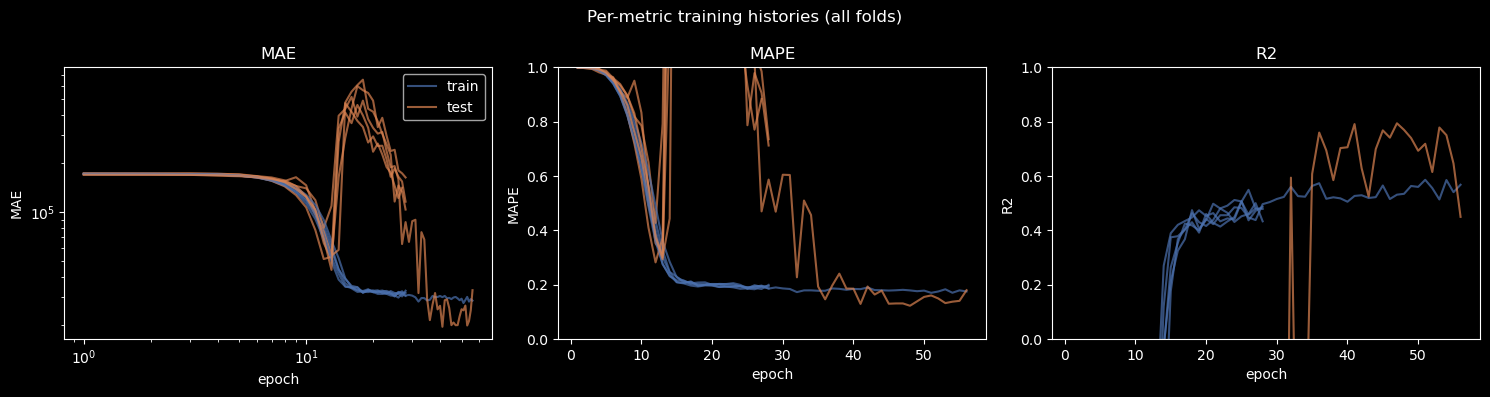

In [23]:
# D3 - BatchNormalization AND Dropout(0.25) together, after each hidden layer.
model = Sequential([
    Input(shape=(X.shape[1],)),

    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),

    Dense(20),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),

    Dense(20),
    Activation('relu'),

    Dense(1, activation='linear'),
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mae')

cv_results['D3 Dropout + BatchNorm'] = run_cv(
    model,
    X,
    y,
    epochs=100,
    batch_size=32,
)

## 3. Comparison

One row per variant: cross-validated means with standard deviations. This is the honest
version of "which model is best" - every number is an average over the same 5 folds.

In [24]:
summary = pd.DataFrame({
    name: {
        'test MAE mean':  res['test MAE'].mean(),
        'test MAPE mean': res['test MAPE'].mean(),
        'test R2 mean':   res['test R2'].mean(),
        'test R2 std':    res['test R2'].std(),
    }
    for name, res in cv_results.items()
}).T

summary.round(3).sort_values('test MAE mean')

,test MAE mean,test MAPE mean,test R2 mean,test R2 std
D2 BatchNorm,12903.698,0.083,0.889,0.020
B8 20 hidden layers (extreme deep),15047.365,0.097,0.864,0.009
A1 batch size 4,15554.582,0.099,0.857,0.007
B5 width 100,16339.261,0.102,0.768,0.078
B7 width 1000 (extreme wide),16374.060,0.103,0.809,0.058
B4 4 hidden layers,16894.230,0.109,0.757,0.094
C2 lr=0.01,17260.148,0.110,0.738,0.092
A2 batch size 16,17414.868,0.112,0.822,0.011
C3 lr=0.1,18156.592,0.115,0.697,0.140
B2 2 hidden layers,18808.941,0.122,0.725,0.072


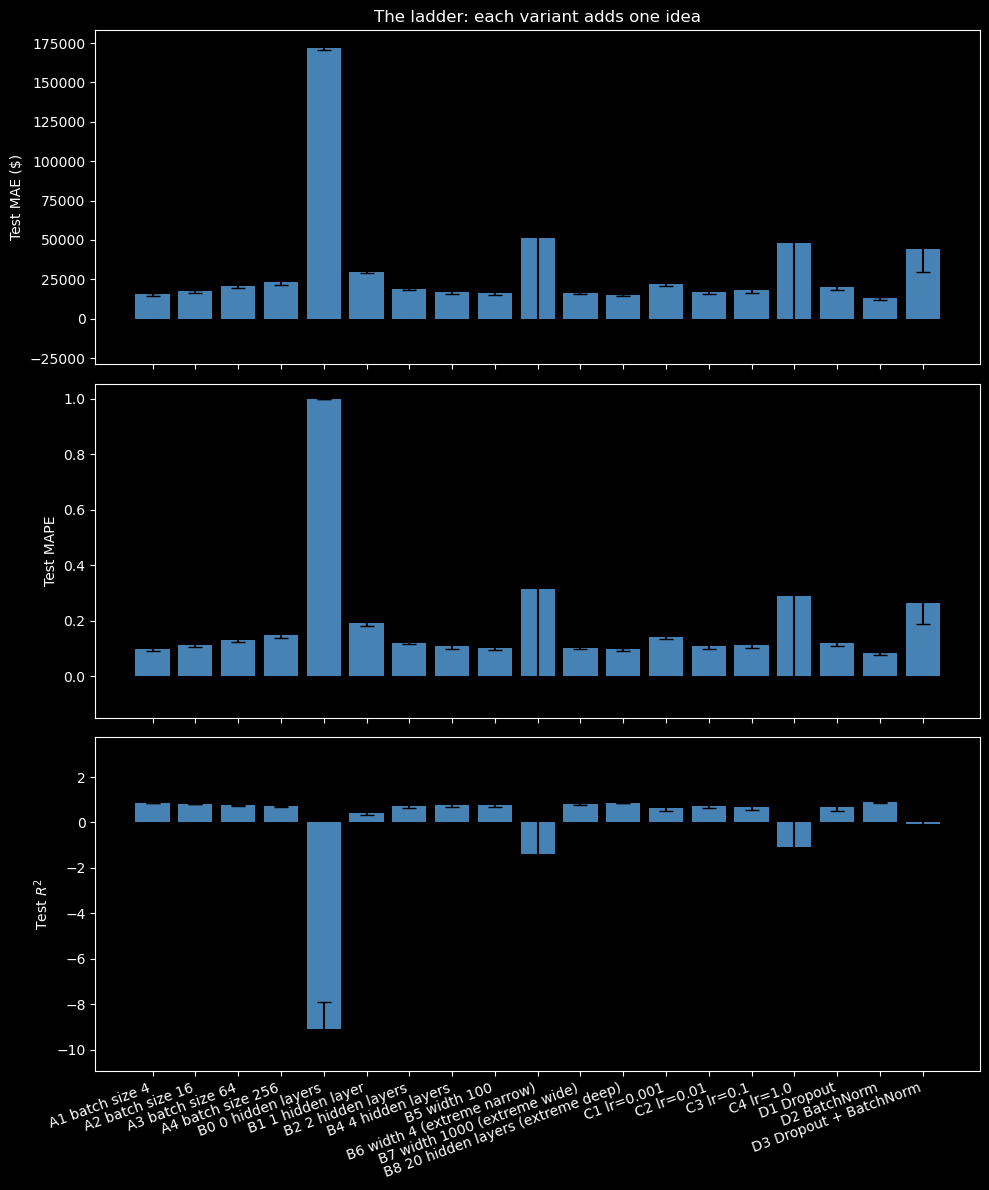

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

names = list(cv_results.keys())
metric_specs = [('test MAE', 'Test MAE ($)'),
                ('test MAPE', 'Test MAPE'),
                ('test R2', 'Test $R^2$')]

for ax, (col, ylabel) in zip(axes, metric_specs):
    means = [cv_results[n][col].mean() for n in names]
    stds  = [cv_results[n][col].std()  for n in names]
    ax.bar(range(len(names)), means, yerr=stds, capsize=5, color='steelblue')
    ax.set_ylabel(ylabel)

axes[-1].set_xticks(range(len(names)))
axes[-1].set_xticklabels(names, rotation=20, ha='right')
axes[0].set_title('The ladder: each variant adds one idea')

plt.tight_layout()
plt.show()

## 4. Review

- **Group A isolates batch size on the cheapest possible model.** A plain linear network sweeps
  `4, 16, 64, 256` before any architecture or optimization decision gets made. Every variant in
  this notebook shares the same 100-epoch budget, so epoch count was never part of the sweep.
- **Group B is the honest architecture sweep — width and depth together, including extremes.**
  Depth from zero to four hidden layers and width from `4` to `1000` units are both varied
  against a three-layer/20-unit standard, plus one deliberately extreme 20-layer-deep case.
- **Group C sweeps the learning rate on that standard architecture**, `0.001` through `1.0` —
  four orders of magnitude — to check whether `0.01` (the value used everywhere else) is
  actually the right choice or just a reasonable-looking default.
- **Group D changes regularization and normalization, individually and combined.** Dropout,
  BatchNormalization, and both together are each tested against the Group B/C standard, so no
  single result gets credited to the wrong technique.
- **Manual CV is what makes every comparison trustworthy.** The error bars in the summary table
  are honest uncertainty; differences smaller than them are noise.
- The same fresh-model-per-fold pattern reappears on the classification spine in
  `U1_Diabetes-4_Keras`.